# Geodesicas en la metrica de Kerr (Boyer-Lindquist)

La metrica que describe el espacio-tiempo alrededor de un cuerpo con simetria esferica pero que rota alrededor del eje $z$ es:

$$
d s^2= \left(1-\frac{2 s r}{\Sigma}\right) c^2 d t^2+\frac{4 a c s^2 r \sin ^2 \theta}{\Sigma} d t d \phi-\frac{\Sigma}{\Delta} d r^2-\Sigma d \theta^2 -\frac{\sin ^2 \theta}{\Sigma}\left[\left(r^2+(a s)^2\right)^2-(a s)^2 \Delta \sin ^2 \theta\right] d \phi^2
$$

donde $s=GM/c^2$ es el parametro de Schwarzschild, $-1<a<1$ es el parametro adimensional de spin y
$$
\Sigma=r^2+(a s)^2 \cos ^2 \theta, \quad \Delta=r^2-2 s r+(a s)^2.
$$

Condiciones iniciales: $r_0 = 10 s$, $v_{\phi,0}=\sqrt{GM/r_0}$. Se comparan tres casos:
1. $a = 0$ (no rotante).
2. $a = 1$ (orbita prograda).
3. $a = -1$ (orbita retrograda).

In [15]:
import einsteinpy.symbolic as es
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pymcel as pc

c:\Users\User\OneDrive\Documentos\Relatividad\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


In [16]:

t, r, theta, phi = sp.symbols('t r theta phi')
G, M, c, a = sp.symbols('G M c a')

# Funciones auxiliares de Boyer-Lindquist
Sigma = r**2 + a**2 * sp.cos(theta)**2
Delta = r**2 - 2*G*M*r/c**2 + a**2

In [ ]:
# Componentes de la métrica de Kerr 
g_00 = 1 - (2*G*M*r) / (c**2 * Sigma)
g_11 = - Sigma / Delta
g_22 = - Sigma
g_33 = - (r**2 + a**2 + (2*G*M*r*a**2 * sp.sin(theta)**2) / (c**2 * Sigma)) * sp.sin(theta)**2
g_03= g_30 = (2*G*M*r*a * sp.sin(theta)**2) / (c**2 * Sigma)

In [ ]:
# Matriz de la métrica [t, r, theta, phi]
g_kerr_mat = sp.Matrix([
    [g_00, 0,    0,      g_03],
    [0,    g_11, 0,      0     ],
    [0,    0,    g_22, 0     ],
    [g_30, 0,  0,      g_33]
])

In [ ]:
coordenadas = [t, r, theta, phi]

gmet = es.MetricTensor(g_kerr_mat.tolist(), coordenadas)
Gab = es.ChristoffelSymbols.from_metric(gmet)

In [ ]:
def edg_kerr(tau, Ys):
    
    t_val, r_val, th_val, ph_val, Ut, Ur, Uth, Uph = Ys
    U = [Ut, Ur, Uth, Uph]
    
    # Derivadas de las posiciones son las cuadrivelocidades
    dt_dtau = Ut
    dr_dtau = Ur
    dth_dtau = Uth
    dph_dtau = Uph
    
    # Inicializar derivadas de las velocidades
    dU_dtau = [0.0, 0.0, 0.0, 0.0]
    
    # Calcular dU^sigma / dtau = - Gamma^sigma_mu_nu * U^mu * U^nu
    for sigma in range(4):
        suma_christoffel = 0.0
        for mu in range(4):
            for nu in range(4):
                # Evaluar numéricamente el símbolo de Christoffel en la posición actual
                gamma_val = es.christoffel_funciones[sigma][mu][nu](t_val, r_val, th_val, ph_val)
                suma_christoffel += gamma_val * U[mu] * U[nu]
        dU_dtau[sigma] = -suma_christoffel
        
    return [dt_dtau, dr_dtau, dth_dtau, dph_dtau, 
            dU_dtau[0], dU_dtau[1], dU_dtau[2], dU_dtau[3]]

## Condiciones iniciales y simulacion
Se usan unidades geometrizadas ($G=M=c=1$) para que $s=1$ y $r_0=10$. Se integra la geodesica para $a=0,1,-1$ y luego se visualiza en 3D.

In [ ]:
# Constantes y condiciones iniciales (unidades geometrizadas)
G_val = 1.0
M_val = 1.0
c_val = 1.0
s = G_val * M_val / c_val**2

t0 = 0.0
r0 = 10 * s
theta0 = np.pi / 2
phi0 = 0.0

# Velocidades espaciales coordinadas (dr/dt, dtheta/dt, dphi/dt)
vr = 0.0
vtheta = 0.0
vphi = np.sqrt(G_val * M_val / r0) / r0

a_values = [0.0, 1.0, -1.0]

T_p = 2 * np.pi * np.sqrt(r0**3 / (G_val * M_val))
taus = np.linspace(0, 50 * T_p, 2500)

trayectorias = []
for a_val in a_values:
    # Convertimos las componentes de Christoffel a funciones numericas legibles por numpy
    Gamma_kerr_num = Gab.tensor().subs({G: G_val, M: M_val, c: c_val, a: a_val})
    christoffel_funciones = []
    for i in range(4):
        fila_i = []
        for j in range(4):
            col_j = []
            for k in range(4):
                # Convertimos cada componente individual a funcion numerica de las coordenadas
                comp_func = sp.lambdify((t, r, theta, phi), Gamma_kerr_num[i, j, k], 'numpy')
                col_j.append(comp_func)
            fila_i.append(col_j)
        christoffel_funciones.append(fila_i)

    # Evaluamos numericamente los coeficientes de la metrica en el punto inicial
    Sigma_0 = r0**2 + (a_val * s)**2 * np.cos(theta0)**2
    Delta_0 = r0**2 - 2 * s * r0 + (a_val * s)**2

    g00 = 1 - (2 * s * r0) / Sigma_0
    g11 = - Sigma_0 / Delta_0
    g22 = - Sigma_0
    g33 = - (r0**2 + (a_val * s)**2 + (2 * s * r0 * (a_val * s)**2 * np.sin(theta0)**2) / Sigma_0) * np.sin(theta0)**2
    g03 = (2 * s * r0 * (a_val * s) * np.sin(theta0)**2) / Sigma_0

    # Terminos espaciales de la ecuacion g_mu_nu * U^mu * U^nu = 1
    termino_espacial = g11 * vr**2 + g22 * vtheta**2 + g33 * vphi**2

    # Resolver la ecuacion de segundo grado para Ut0
    A = g00 + 2 * g03 * vphi
    B = 0.0
    C = termino_espacial - 1.0
    Ut0 = (-B + np.sqrt(B**2 - 4 * A * C)) / (2 * A)

    # Componentes de la cuadrivelocidad inicial
    Ur0 = vr * Ut0
    Utheta0 = vtheta * Ut0
    Uphi0 = vphi * Ut0
    Ys0 = [t0, r0, theta0, phi0, Ut0, Ur0, Utheta0, Uphi0]

    sol = solve_ivp(edg_kerr, (taus[0], taus[-1]), Ys0, t_eval=taus, method='Radau')

    # Extraccion de coordenadas de la solucion
    r_sol = sol.y[1]
    theta_sol = sol.y[2]
    phi_sol = sol.y[3]

    # Transformacion a coordenadas cartesianas para visualizacion en 3D
    x_sol = r_sol * np.sin(theta_sol) * np.cos(phi_sol)
    y_sol = r_sol * np.sin(theta_sol) * np.sin(phi_sol)
    z_sol = r_sol * np.cos(theta_sol)

    # Radio del horizonte de sucesos externo de Kerr: r_+ = M + sqrt(M^2 - a^2)
    r_horizonte = M_val + np.sqrt(M_val**2 - a_val**2)

    trayectorias.append({
        "a_val": a_val,
        "x": x_sol,
        "y": y_sol,
        "z": z_sol,
        "r_horizonte": r_horizonte
    })

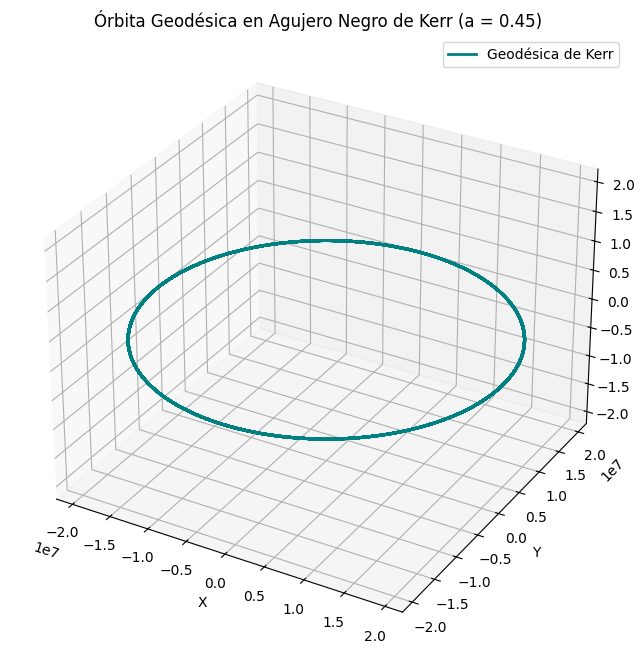

In [ ]:
# Graficar las trayectorias
fig = plt.figure(figsize=(15, 5))
colores = ['teal', 'crimson', 'goldenrod']

for idx, tr in enumerate(trayectorias):
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    ax.plot(tr["x"], tr["y"], tr["z"], color=colores[idx], lw=2)

    # Agujero negro (esfera de radio r_+)
    u, v = np.linspace(0, 2 * np.pi, 100), np.linspace(0, np.pi, 100)
    x_bh = tr["r_horizonte"] * np.outer(np.cos(u), np.sin(v))
    y_bh = tr["r_horizonte"] * np.outer(np.sin(u), np.sin(v))
    z_bh = tr["r_horizonte"] * np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_surface(x_bh, y_bh, z_bh, color='black', alpha=0.6)

    ax.set_title(f"a = {tr['a_val']}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    # Forzar relacion de aspecto igual
    max_range = np.array([
        tr["x"].max() - tr["x"].min(),
        tr["y"].max() - tr["y"].min(),
        tr["z"].max() - tr["z"].min()
    ]).max() / 2.0
    mid_x = (tr["x"].max() + tr["x"].min()) * 0.5
    mid_y = (tr["y"].max() + tr["y"].min()) * 0.5
    mid_z = (tr["z"].max() + tr["z"].min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

plt.tight_layout()
plt.show()